# 04 — Pathway Enrichment & Biological Interpretation

**Input:** `results/de_analysis/ranked_gene_list_gsea.csv`  
**Output:** `results/pathway/` — enrichment results and plots

---

## Goal
Translate the 691 significant DEGs from notebook 03 into biological pathways and resistance mechanisms. Individual genes are difficult to interpret in isolation pathway analysis groups them into coordinated biological processes that are easier to understand and validate.


In [3]:
# Library preparartion.
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gseapy as gp
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# Reproducible repo root
repo_root = os.path.dirname(os.getcwd())
sys.path.insert(0, repo_root)
from scripts.utils.config import *

# Fix paths
RESULTS_PATH = os.path.join(repo_root, 'results', 'pathway')
RESULTS_DE   = os.path.join(repo_root, 'results', 'de_analysis')
os.makedirs(RESULTS_PATH, exist_ok=True)

np.random.seed(RANDOM_SEED)

print('Libraries loaded.')
print('Repo root:', os.path.basename(repo_root))

Libraries loaded.
Repo root: aml-treatment-resistance


In [4]:
# ── LOAD DE RESULTS FROM NOTEBOOK 03 
ranked     = pd.read_csv(os.path.join(RESULTS_DE, 'ranked_gene_list_gsea.csv'),
                         index_col=0)
up_genes   = pd.read_csv(os.path.join(RESULTS_DE, 'de_upregulated.csv'),
                         index_col=0).index.tolist()
down_genes = pd.read_csv(os.path.join(RESULTS_DE, 'de_downregulated.csv'),
                         index_col=0).index.tolist()

ranked_series = ranked['log2FoldChange']

print('=' * 50)
print('DE RESULTS LOADED')
print('=' * 50)
print(f'Ranked gene list: {len(ranked_series):,} genes')
print(f'Upregulated:      {len(up_genes):,} genes')
print(f'Downregulated:    {len(down_genes):,} genes')
print(f'\nTop 5 upregulated:   {up_genes[:5]}')
print(f'Top 5 downregulated: {down_genes[:5]}')

DE RESULTS LOADED
Ranked gene list: 14,453 genes
Upregulated:      449 genes
Downregulated:    242 genes

Top 5 upregulated:   ['MIR650', 'CTSE', 'FAM178B', 'SLC25A21', 'HCN3']
Top 5 downregulated: ['SCUBE1', 'HOXA-AS3', 'APOC2', 'SPAG6', 'TPSAB1']


In [5]:
# ── GSEA — MSigDB Hallmark gene sets
print('Running GSEA on MSigDB Hallmark gene sets...')
print('Using full ranked gene list — no significance threshold needed')

gsea_res = gp.prerank(
    rnk             = ranked_series,
    gene_sets       = 'MSigDB_Hallmark_2020',
    outdir          = os.path.join(RESULTS_PATH, 'gsea_hallmark'),
    min_size        = 15,
    max_size        = 500,
    permutation_num = 1000,
    seed            = RANDOM_SEED,
    verbose         = False
)

gsea_df = gsea_res.res2d.sort_values('FDR q-val')

print('GSEA complete.')
print(f'\nTotal pathways tested: {gsea_df.shape[0]}')
print(f'Significant (FDR < 0.25): {(gsea_df["FDR q-val"] < 0.25).sum()}')
print(f'\nTop enriched pathways:')
print(gsea_df[['NES', 'NOM p-val', 'FDR q-val']].head(15))

Running GSEA on MSigDB Hallmark gene sets...
Using full ranked gene list — no significance threshold needed
GSEA complete.

Total pathways tested: 50
Significant (FDR < 0.25): 32

Top enriched pathways:
         NES  NOM p-val  FDR q-val
0   2.636701   0.001000   0.001000
1   2.005808   0.001000   0.001000
2   1.894572   0.001000   0.001000
3   1.888711   0.001000   0.001000
6   1.698934   0.006957   0.005847
5   1.704386   0.008711   0.006253
4   1.719781   0.001000   0.006367
7   1.646037   0.001000   0.008243
8   1.585205   0.001000   0.016801
10  1.562409   0.001000   0.018191
9   1.562498   0.001000   0.020010
11  1.526232   0.001353   0.024823
13  1.478213   0.011445   0.038393
16  1.402571   0.084459   0.078854
17  1.385365   0.048137   0.086027


In [8]:
# ── DISPLAY GSEA RESULTS WITH CORRECT PATHWAY NAMES ───────────────────────────
sig_gsea = gsea_df[gsea_df['FDR q-val'] < 0.25].copy()

print(f'Significant pathways (FDR < 0.25): {len(sig_gsea)}')
print('=' * 70)

for _, row in sig_gsea.iterrows():
    direction = '▲ UP  ' if row['NES'] > 0 else '▼ DOWN'
    print(f"{direction} | NES: {row['NES']:6.3f} | FDR: {row['FDR q-val']:.4f} | {row['Term']}")

Significant pathways (FDR < 0.25): 32
▲ UP   | NES:  2.637 | FDR: 0.0010 | heme Metabolism
▲ UP   | NES:  2.006 | FDR: 0.0010 | Allograft Rejection
▲ UP   | NES:  1.895 | FDR: 0.0010 | Interferon Alpha Response
▲ UP   | NES:  1.889 | FDR: 0.0010 | Interferon Gamma Response
▲ UP   | NES:  1.699 | FDR: 0.0058 | Pancreas Beta Cells
▲ UP   | NES:  1.704 | FDR: 0.0063 | Hedgehog Signaling
▲ UP   | NES:  1.720 | FDR: 0.0064 | Complement
▲ UP   | NES:  1.646 | FDR: 0.0082 | Epithelial Mesenchymal Transition
▲ UP   | NES:  1.585 | FDR: 0.0168 | IL-2/STAT5 Signaling
▲ UP   | NES:  1.562 | FDR: 0.0182 | Estrogen Response Early
▲ UP   | NES:  1.562 | FDR: 0.0200 | E2F Targets
▲ UP   | NES:  1.526 | FDR: 0.0248 | G2-M Checkpoint
▲ UP   | NES:  1.478 | FDR: 0.0384 | UV Response Dn
▲ UP   | NES:  1.403 | FDR: 0.0789 | Apical Surface
▲ UP   | NES:  1.385 | FDR: 0.0860 | TGF-beta Signaling
▲ UP   | NES:  1.379 | FDR: 0.0869 | Bile Acid Metabolism
▼ DOWN | NES: -1.404 | FDR: 0.0923 | Cholesterol Homeos

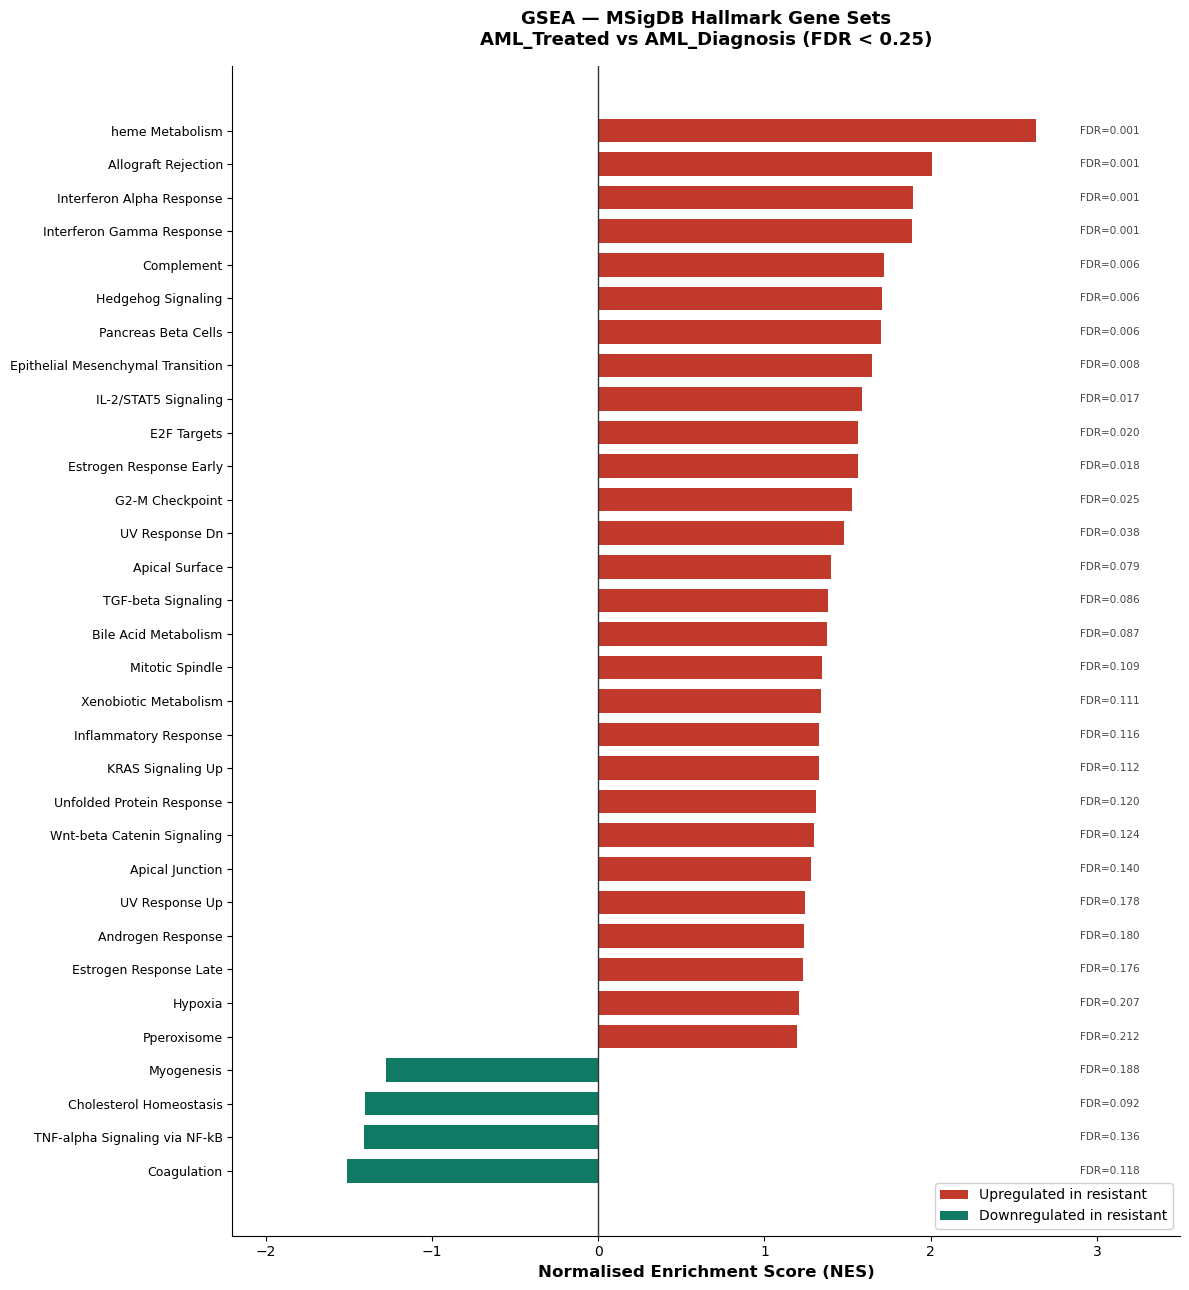

GSEA bar plot saved.


In [10]:
# ── GSEA BAR PLOT — cleaned up ─────────────────────────────────────────────────
sig_gsea = gsea_df[gsea_df['FDR q-val'] < 0.25].copy()
sig_gsea = sig_gsea.sort_values('NES')

colours = ['#117A65' if x < 0 else '#C0392B' for x in sig_gsea['NES']]

fig, ax = plt.subplots(figsize=(12, 13))
ax.barh(sig_gsea['Term'], sig_gsea['NES'],
        color=colours, edgecolor='none', height=0.7)

ax.axvline(0, color='#333333', lw=1.0)

# X axis limits — give space for FDR labels
ax.set_xlim(-2.2, 3.5)

ax.set_xlabel('Normalised Enrichment Score (NES)',
              fontsize=12, fontweight='bold')
ax.set_title('GSEA — MSigDB Hallmark Gene Sets\n'
             'AML_Treated vs AML_Diagnosis (FDR < 0.25)',
             fontsize=13, fontweight='bold', pad=15)

# FDR labels — fixed position outside bars
for _, row in sig_gsea.iterrows():
    ax.text(2.9, row['Term'],
            f"FDR={row['FDR q-val']:.3f}",
            va='center', ha='left',
            fontsize=7.5, color='#444444')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#C0392B', label='Upregulated in resistant'),
    Patch(facecolor='#117A65', label='Downregulated in resistant')
]
ax.legend(handles=legend_elements, fontsize=10,
          loc='lower right', framealpha=0.9)

ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='y', labelsize=9)
ax.tick_params(axis='x', labelsize=10)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'gsea_hallmark_barplot.png'),
            dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('GSEA bar plot saved.')

In [12]:
# ── ORA — GO Biological Process 
print('Running GO Biological Process enrichment...')

go_up = gp.enrichr(
    gene_list = up_genes,
    gene_sets = 'GO_Biological_Process_2021',
    outdir    = os.path.join(RESULTS_PATH, 'go_upregulated'),
    cutoff    = 0.05
)

print('GO enrichment complete.')
print(f'\nSignificant GO terms (padj < 0.05): {(go_up.results["Adjusted P-value"] < 0.05).sum()}')
print('\nTop 15 GO terms:')
print(go_up.results[['Term', 'Adjusted P-value', 'Overlap']]
      .head(15).to_string(index=False))

Running GO Biological Process enrichment...
GO enrichment complete.

Significant GO terms (padj < 0.05): 60

Top 15 GO terms:
                                                                         Term  Adjusted P-value Overlap
                        positive regulation of T cell activation (GO:0050870)      2.325514e-07   15/75
                                               T cell activation (GO:0042110)      2.357752e-06   15/92
                            regulation of T cell differentiation (GO:0045580)      8.280963e-06   10/39
                     antigen receptor-mediated signaling pathway (GO:0050851)      2.349853e-05  19/185
                             cytokine-mediated signaling pathway (GO:0019221)      3.625089e-05  37/621
positive regulation of natural killer cell mediated cytotoxicity (GO:0045954)      5.996843e-05    7/20
                      positive regulation of cytokine production (GO:0001819)      5.996843e-05  25/335
         regulation of natural killer cell

In [14]:
# ── ORA — KEGG Pathways 
print('Running KEGG enrichment...')

kegg_up = gp.enrichr(
    gene_list = up_genes,
    gene_sets = 'KEGG_2021_Human',
    outdir    = os.path.join(RESULTS_PATH, 'kegg_upregulated'),
    cutoff    = 0.05
)

print('KEGG enrichment complete.')
print(f'\nSignificant KEGG pathways (padj < 0.05): {(kegg_up.results["Adjusted P-value"] < 0.05).sum()}')
print('\nTop 15 KEGG pathways:')
print(kegg_up.results[['Term', 'Adjusted P-value', 'Overlap']]
      .head(15).to_string(index=False))

Running KEGG enrichment...
KEGG enrichment complete.

Significant KEGG pathways (padj < 0.05): 15

Top 15 KEGG pathways:
                                                         Term  Adjusted P-value Overlap
                            T cell receptor signaling pathway      4.092229e-10  19/104
                                   Hematopoietic cell lineage      6.888740e-07   15/99
                                      Cell adhesion molecules      3.216964e-06  17/148
                       Cytokine-cytokine receptor interaction      3.823765e-06  24/295
                                    Th17 cell differentiation      5.978548e-06  14/107
                             Th1 and Th2 cell differentiation      4.117281e-05   12/92
                                     Primary immunodeficiency      5.327280e-05    8/38
                                   Inflammatory bowel disease      5.327280e-05   10/65
Viral protein interaction with cytokine and cytokine receptor      6.759263e-05  12/100

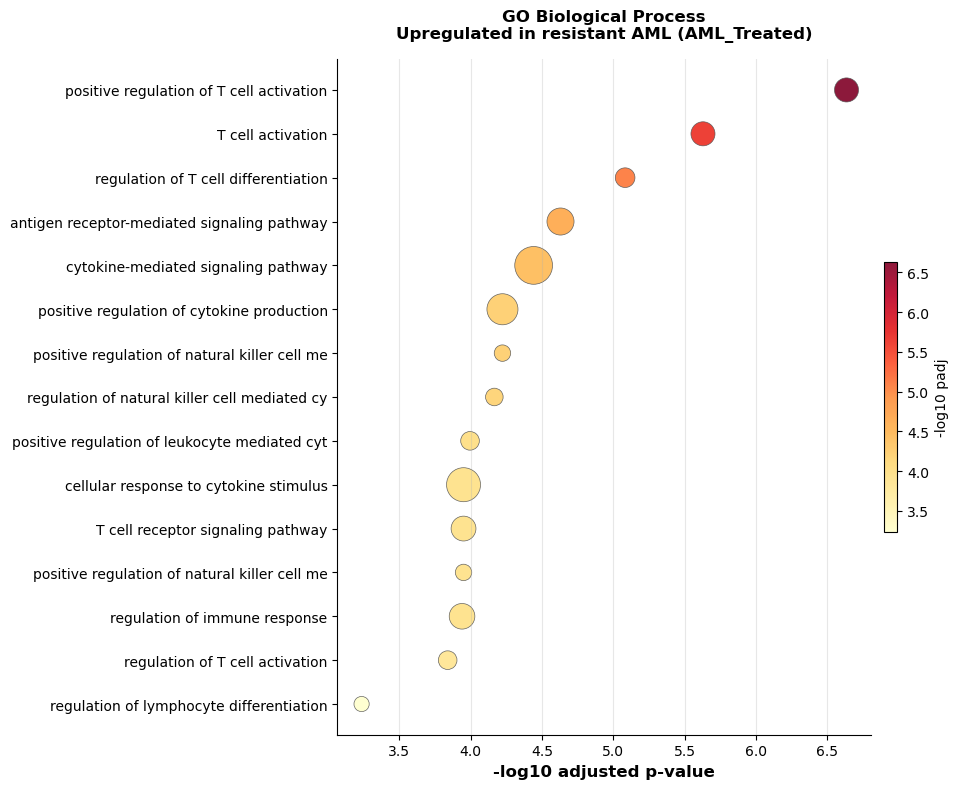

GO plot saved.


In [18]:
# ── GO PLOT 
go_df = go_up.results.copy()
go_df = go_df[go_df['Adjusted P-value'] < 0.05].head(15)
go_df['-log10_padj'] = -np.log10(go_df['Adjusted P-value'])
go_df['gene_count']  = go_df['Overlap'].apply(lambda x: int(x.split('/')[0]))
go_df = go_df.sort_values('-log10_padj', ascending=True)
go_df['Term_clean']  = go_df['Term'].apply(lambda x: x.split('(')[0].strip()[:45])

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    go_df['-log10_padj'],
    range(len(go_df)),
    s          = go_df['gene_count'] * 20,
    c          = go_df['-log10_padj'],
    cmap       = 'YlOrRd',
    alpha      = 0.9,
    edgecolors = '#555555',
    linewidths = 0.5
)
ax.set_yticks(range(len(go_df)))
ax.set_yticklabels(go_df['Term_clean'], fontsize=10)
ax.set_xlabel('-log10 adjusted p-value', fontsize=12, fontweight='bold')
ax.set_title('GO Biological Process\nUpregulated in resistant AML (AML_Treated)',
             fontsize=12, fontweight='bold', pad=15)
plt.colorbar(scatter, ax=ax, label='-log10 padj', shrink=0.4, pad=0.02)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'go_dotplot.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('GO plot saved.')

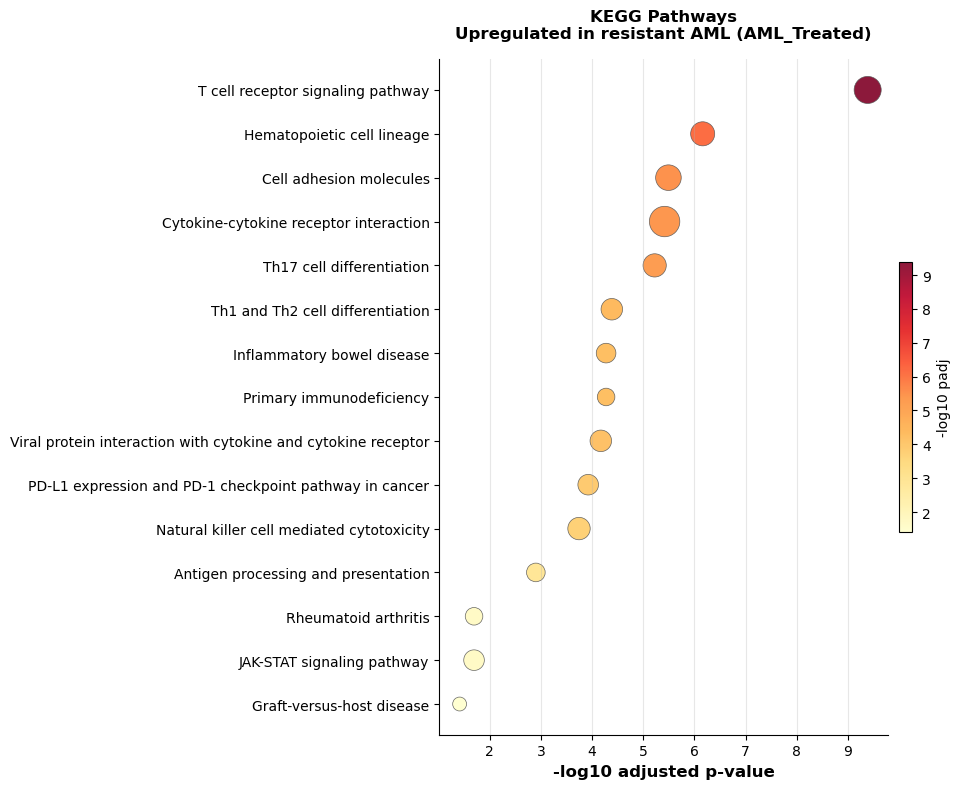

KEGG plot saved.


In [19]:
# ── KEGG PLOT 
kegg_df = kegg_up.results.copy()
kegg_df = kegg_df[kegg_df['Adjusted P-value'] < 0.05].head(15)
kegg_df['-log10_padj'] = -np.log10(kegg_df['Adjusted P-value'])
kegg_df['gene_count']  = kegg_df['Overlap'].apply(lambda x: int(x.split('/')[0]))
kegg_df = kegg_df.sort_values('-log10_padj', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    kegg_df['-log10_padj'],
    range(len(kegg_df)),
    s          = kegg_df['gene_count'] * 20,
    c          = kegg_df['-log10_padj'],
    cmap       = 'YlOrRd',
    alpha      = 0.9,
    edgecolors = '#555555',
    linewidths = 0.5
)
ax.set_yticks(range(len(kegg_df)))
ax.set_yticklabels(kegg_df['Term'], fontsize=10)
ax.set_xlabel('-log10 adjusted p-value', fontsize=12, fontweight='bold')
ax.set_title('KEGG Pathways\nUpregulated in resistant AML (AML_Treated)',
             fontsize=12, fontweight='bold', pad=15)
plt.colorbar(scatter, ax=ax, label='-log10 padj', shrink=0.4, pad=0.02)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'kegg_dotplot.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('KEGG plot saved.')

In [22]:
# ── REACTOME ENRICHMENT ────────────────────────────────────────────────────────
reactome_up = gp.enrichr(
    gene_list = up_genes,
    gene_sets = 'Reactome_2022',
    outdir    = os.path.join(RESULTS_PATH, 'reactome_upregulated'),
    cutoff    = 0.05
)

print('Significant Reactome pathways:')
print(reactome_up.results[
    reactome_up.results['Adjusted P-value'] < 0.05
][['Term', 'Adjusted P-value', 'Overlap']].head(15).to_string(index=False))

Significant Reactome pathways:
                                                                                 Term  Adjusted P-value Overlap
Immunoregulatory Interactions Between A Lymphoid And A non-Lymphoid Cell R-HSA-198933          0.000002  17/123
                                                           Immune System R-HSA-168256          0.000006 82/1943
                                                 Adaptive Immune System R-HSA-1280218          0.000006  42/733
                                            Costimulation By CD28 Family R-HSA-388841          0.000006   12/68
                                    Cytokine Signaling In Immune System R-HSA-1280215          0.000237  37/702
                                                        DAP12 Signaling R-HSA-2424491          0.000281    7/28
                                             Nef And Signal Transduction R-HSA-164944          0.001820     4/8
               Role Of Nef In HIV-1 Replication And Disease Pathogenesis 

In [23]:
# ── BIOMARKER PRIORITISATION ───────────────────────────────────────────────────
# Prioritise genes that are:
# 1. Statistically significant (low padj)
# 2. Biologically large effect (high log2FC)
# 3. Appear in multiple pathway analyses

# Genes in KEGG PD-L1 pathway
pdl1_pathway_genes = ['CD274', 'PDCD1', 'CD8A', 'CD8B',
                       'IFNG', 'JAK1', 'JAK2', 'STAT1']

# Genes in GSEA leading edge (Interferon response)
interferon_leading = gsea_df[
    gsea_df['Term'] == 'Interferon Gamma Response'
]['Lead_genes'].values[0].split(';')[:10]

print('Top biomarker candidates:')
print('\n1. HOXA cluster — downregulated in resistance:')
hoxa = [g for g in down_genes if 'HOX' in g]
print(f'   {hoxa}')

print('\n2. Immune checkpoint genes — upregulated:')
checkpoint = [g for g in up_genes if g in ['CD274', 'PDCD1LG2', 'LAG3', 'TIGIT']]
print(f'   {checkpoint}')

print('\n3. Top DEGs by combined score (log2FC × -log10padj):')
sig = pd.read_csv(os.path.join(RESULTS_DE, 'de_results_significant.csv'), index_col=0)
sig['combined_score'] = sig['log2FoldChange'].abs() * -np.log10(sig['padj'])
print(sig.sort_values('combined_score', ascending=False).head(10)[
    ['log2FoldChange', 'padj', 'combined_score']])

Top biomarker candidates:

1. HOXA cluster — downregulated in resistance:
   ['HOXA-AS3', 'HOXA6', 'HOXA3', 'HOXA4', 'HOXA5', 'HOXA7', 'HOXA9', 'HOXA10', 'HOXB3', 'HOXA10-AS']

2. Immune checkpoint genes — upregulated:
   ['TIGIT', 'CD274']

3. Top DEGs by combined score (log2FC × -log10padj):
          log2FoldChange      padj  combined_score
Gene                                              
KCNH2           3.825451  0.000012       18.760032
HOXA-AS3       -3.814363  0.000038       16.863934
SLC25A21        4.443448  0.000300       15.651682
CD8A            2.947732  0.000012       14.513845
FAM178B         4.472972  0.000597       14.420914
SYDE2           2.867560  0.000010       14.393922
CD3E            3.022559  0.000023       13.992074
HCN3            3.997315  0.000334       13.895901
TIAM1           2.893920  0.000019       13.686929
KLRK1           2.462390  0.000007       12.692400


## Biomarker Prioritisation — What I Found

### HOXA cluster — most striking finding
10 HOX genes are consistently downregulated in resistant AML:
HOXA3, HOXA4, HOXA5, HOXA6, HOXA7, HOXA9, HOXA10, 
HOXA-AS3, HOXA10-AS, HOXB3

An entire gene cluster lost together — this is not random noise.
HOXA genes control normal blood cell development. Their loss 
in resistant cells suggests chemotherapy selects for cells 
that have abandoned the normal haematopoietic programme.

### Immune checkpoint genes — clinically important
Two immune checkpoint genes upregulated in resistant cells:
- **CD274 (PD-L1)** — helps AML cells hide from T cells
- **TIGIT** — another checkpoint, blocks immune killing

Both are drug targets — PD-L1 inhibitors and TIGIT 
blockers are already in clinical trials for AML.

### Top genes by combined statistical + biological score

| Gene | Direction | Role |
|------|-----------|------|
| KCNH2 | Up in resistant | Potassium channel |
| HOXA-AS3 | Down in resistant | HOXA cluster regulator |
| SLC25A21 | Up in resistant | Mitochondrial carrier |
| CD8A, CD3E | Up in resistant | T cell markers |
| KLRK1 | Up in resistant | NK cell receptor |

### Note on CD8A and CD3E
These are T cell markers appearing as top DEGs — this 
likely reflects more T cells present in post-chemotherapy 
bone marrow rather than AML blasts expressing T cell genes. 
Running DE within each cell type separately in future 
analysis would separate these effects cleanly.

In [26]:
# ── SAVE ALL RESULTS 
gsea_df.to_csv(os.path.join(RESULTS_PATH, 'gsea_hallmark_results.csv'))
go_up.results.to_csv(os.path.join(RESULTS_PATH, 'go_bp_upregulated.csv'))
kegg_up.results.to_csv(os.path.join(RESULTS_PATH, 'kegg_upregulated.csv'))

print('All results saved:')
print(f'  gsea_hallmark_results.csv — {gsea_df.shape[0]} pathways')
print(f'  go_bp_upregulated.csv     — {go_up.results.shape[0]} GO terms')
print(f'  kegg_upregulated.csv      — {kegg_up.results.shape[0]} KEGG pathways')


All results saved:
  gsea_hallmark_results.csv — 50 pathways
  go_bp_upregulated.csv     — 2378 GO terms
  kegg_upregulated.csv      — 244 KEGG pathways
